In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Multiply and Accumulate

### Setup

In [5]:
from IPython.display import display_svg
from typing import List, Tuple
import random
import torch
import numpy as np
import pandas as pd
from itertools import combinations_with_replacement
from typing import Callable, Any
import pyrtl
from pyrtl.rtllib.libutils import twos_comp_repr, rev_twos_comp_repr
from pyrtl import (
    WireVector, 
    Const, 
    Input,
    Output, 
    Register, 
    Simulation, 
    SimulationTrace, 
    reset_working_block
)
from kai.src.utils import custom_render_trace, basic_circuit_analysis
from kai.src.bfloat16 import BF16

In [6]:
E_BITS  = 8
M_BITS  = 7
MSB     = E_BITS + M_BITS

### PyRTL Simple Pipeline

In [7]:
class SimplePipeline(object):
    """ Pipeline builder with auto generation of pipeline registers. """

    def __init__(self):
        self._pipeline_register_map = {}
        self._current_stage_num = 0
        stage_list = [method for method in dir(self) if method.startswith('stage')]
        for stage in sorted(stage_list):
            stage_method = getattr(self, stage)
            stage_method()
            self._current_stage_num += 1

    def __getattr__(self, name):
        try:
            return self._pipeline_register_map[self._current_stage_num][name]
        except KeyError:
            raise pyrtl.PyrtlError(
                'error, no pipeline register "%s" defined for stage %d'
                % (name, self._current_stage_num))

    def __setattr__(self, name, value):
        if name.startswith('_'):
            # do not do anything tricky with variables starting with '_'
            object.__setattr__(self, name, value)
        else:
            next_stage = self._current_stage_num + 1
            pipereg_id = str(self._current_stage_num) + 'to' + str(next_stage)
            rname = 'pipereg_' + pipereg_id + '_' + name
            new_pipereg = pyrtl.Register(bitwidth=len(value), name=rname)
            if next_stage not in self._pipeline_register_map:
                self._pipeline_register_map[next_stage] = {}
            self._pipeline_register_map[next_stage][name] = new_pipereg
            new_pipereg.next <<= value

## A Basic MAC Example

Testing pipelined MAC:


<IPython.core.display.Javascript object>

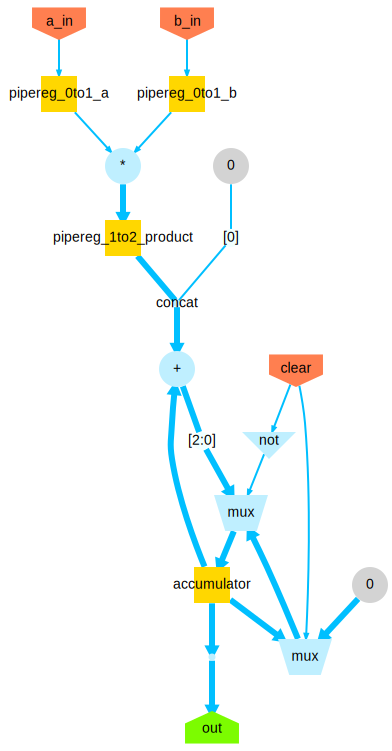

In [8]:
pyrtl.reset_working_block()

class PipelineMAC(SimplePipeline):
    def __init__(self):
        # Create accumulator register outside pipeline stages
        self._accumulator = pyrtl.Register(3, 'accumulator')
        self._out = pyrtl.Output(3, 'out')
        # Create clear signal to reset accumulator
        self._clear = pyrtl.Input(1, 'clear')
        super(PipelineMAC, self).__init__()
        
    def stage0(self):
        # Input stage - receive operands
        self.a = pyrtl.Input(1, 'a_in')
        self.b = pyrtl.Input(1, 'b_in')
        
    def stage1(self):
        # Multiply stage
        self.product = self.a * self.b
        
    def stage2(self):
        # Add stage with accumulation
        with pyrtl.conditional_assignment:
            with self._clear:
                self._accumulator.next |= 0
            with pyrtl.otherwise:
                self._accumulator.next |= self.product + self._accumulator
        
        # Connect accumulator to output
        self._out <<= self._accumulator

def test_pipeline_mac():
    pipelinemac = PipelineMAC()
    # pyrtl.synthesize()
    # pyrtl.optimize()
    sim_trace = pyrtl.SimulationTrace()
    sim = pyrtl.Simulation(tracer=sim_trace)
    
    # Test vectors
    inputs = {
        'a_in':    [1, 1, 1, 0, 1, 0, 0],
        'b_in':    [1, 1, 1, 1, 0, 0, 0],
        'clear':   [1, 0, 0, 0, 0, 0, 0]  # Clear first, then accumulate
    }
    
    sim.step_multiple(inputs)
    custom_render_trace(sim_trace, repr_func=lambda x: int(x))

print("Testing pipelined MAC:")
test_pipeline_mac()

svg = pyrtl.block_to_svg(split_state=False)
display_svg(svg, raw=True)